In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.models.apogee import Spectrum
from ugdatalab.methods.cannon import CannonModel
from ugdatalab.methods.cannon_likelihood import CannonLabelLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample
from ugdatalab.plotters.bayesian import plot_corner, plot_trace
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone  # TODO(audit-H8): replace with public wrapper

import plotters


In [2]:
# Load trained Cannon model
model_data = np.load("cannon_model.npz", allow_pickle=True)
model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)
print(f"Cannon model loaded: chi2_r = {model.chi2_r:.3f}")

Cannon model loaded: chi2_r = 0.998


## Problem 12 — MCMC Label Fitting of the Mystery Spectrum

### Read and normalize the mystery spectrum

In [3]:
mystery_path = Path("../../course_materials_sp2026/labs/lab_2/mystery_spec_wiped.fits")
continuum_path = Path("continuum_wavelengths.npz")

mystery = Spectrum(mystery_path, continuum_path)
flux_norm = mystery.flux[0]
error_norm = mystery.error[0]

valid = np.isfinite(flux_norm) & (error_norm < np.inf)
print(f"Mystery spectrum: {np.sum(valid)} valid pixels out of {len(flux_norm)}")

Mystery spectrum: 7721 valid pixels out of 8575


### Likelihood, priors, and sampler

**Likelihood.** Holding the trained Cannon model fixed (i.e., $\boldsymbol{\theta}_\lambda$ and $s_\lambda^2$ are not free parameters here — they were optimized in NB 02), the Cannon's prediction at the trial label vector $\boldsymbol{\ell}$ is the deterministic spectrum $\hat{f}_\lambda(\boldsymbol{\ell}) = \mathbf{X}(\boldsymbol{\ell}) \cdot \boldsymbol{\theta}_\lambda$. The observed mystery flux at each pixel is modeled as an independent Gaussian:

$$f_\lambda^{\rm obs} \;\sim\; \mathcal{N}\!\left(\hat{f}_\lambda(\boldsymbol{\ell}),\;\; \sigma_\lambda^2 + s_\lambda^2\right)$$

so the joint log-likelihood over all valid pixels is:

$$\ln \mathcal{L}(\boldsymbol{\ell}) \;=\; -\frac{1}{2}\sum_\lambda \left[\ln\bigl(2\pi(\sigma_\lambda^2 + s_\lambda^2)\bigr) + \frac{(f_\lambda^{\rm obs} - \hat{f}_\lambda(\boldsymbol{\ell}))^2}{\sigma_\lambda^2 + s_\lambda^2}\right].$$

This is the same Gaussian-noise functional form used in NB 02 for training, but with the *labels* as the free parameters and the polynomial coefficients held fixed. The pixel-wise independence assumption is the key simplification — it is the approximation that we will see breaks down in the uncertainty discussion below.

**Priors.** We place weakly informative Normal priors on each label centered on the training-set means with width $2\sigma$ (training-set standard deviations):

$$\ell_i \;\sim\; \mathcal{N}\!\left(\mu_i,\; (2\sigma_i)^2\right).$$

The $2\sigma$ width covers the bulk of the training-set support (~95%) so the prior is essentially flat across the region the Cannon was actually trained on, while still penalizing wild excursions outside it. With likelihood $\chi^2_r \sim 10$ (see below), the data overwhelmingly dominate the posterior; the prior choice has only a marginal effect on the posterior medians (the prior and posterior widths differ by orders of magnitude). A $1\sigma$ prior would be too aggressive (would shift posterior medians by an appreciable fraction of the prior width); a $3\sigma$ prior would let the sampler wander outside the training support where the polynomial extrapolates poorly. $2\sigma$ is the sweet spot.

**Why NUTS, not Metropolis–Hastings?** The Cannon's polynomial likelihood is differentiable in closed form (the design vector is a quadratic polynomial in the labels and the prediction is linear in $\boldsymbol{\theta}$, so $\partial \hat{f}_\lambda / \partial \ell_i$ is analytic). The No-U-Turn Sampler (NUTS; Hoffman & Gelman 2014) is a gradient-based Hamiltonian Monte Carlo variant that exploits this gradient to take long, decorrelated steps through the joint posterior — typically achieving 100–1000× higher effective sample size per gradient evaluation than naive Metropolis–Hastings on correlated 5-dimensional posteriors. The cost is that we need a gradient at every step, which the Cannon supplies for free. Pure MH would also work for a 5-dimensional problem, but would need on the order of $10\times$ more steps to reach the same $\hat R$ and effective sample size, with a worse acceptance rate.

In [4]:
prior_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Prior mean (μ)": model.label_means,
    "Prior width (2σ)": 2 * model.label_stds,
})
prior_df

,Label,Prior mean (μ),Prior width (2σ)
0,TEFF,4591.772529,814.656903
1,LOGG,2.373584,1.472003
2,FE_H,-0.111261,0.521406
3,MG_FE,0.096135,0.229159
4,SI_FE,0.046801,0.169138


### MCMC fit

In [5]:
lk = CannonLabelLikelihood(
    x=model.wavelength,
    y=flux_norm,
    y_err=error_norm,
    model=model,
)
result = nuts_sample(lk, n_steps=2000, n_burn=1000, seed=42)
print(f"MCMC chi2_r: {result.chi2_r:.3f}")
print(f"Posterior median labels: {result.theta}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [TEFF, LOGG, FE_H, MG_FE, SI_FE]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 56 seconds.


MCMC chi2_r: 0.599
Posterior median labels: [ 4.58176043e+03  1.98905494e+00 -6.09538959e-01  3.14688611e-01
  2.07427489e-01]


### Corner plot

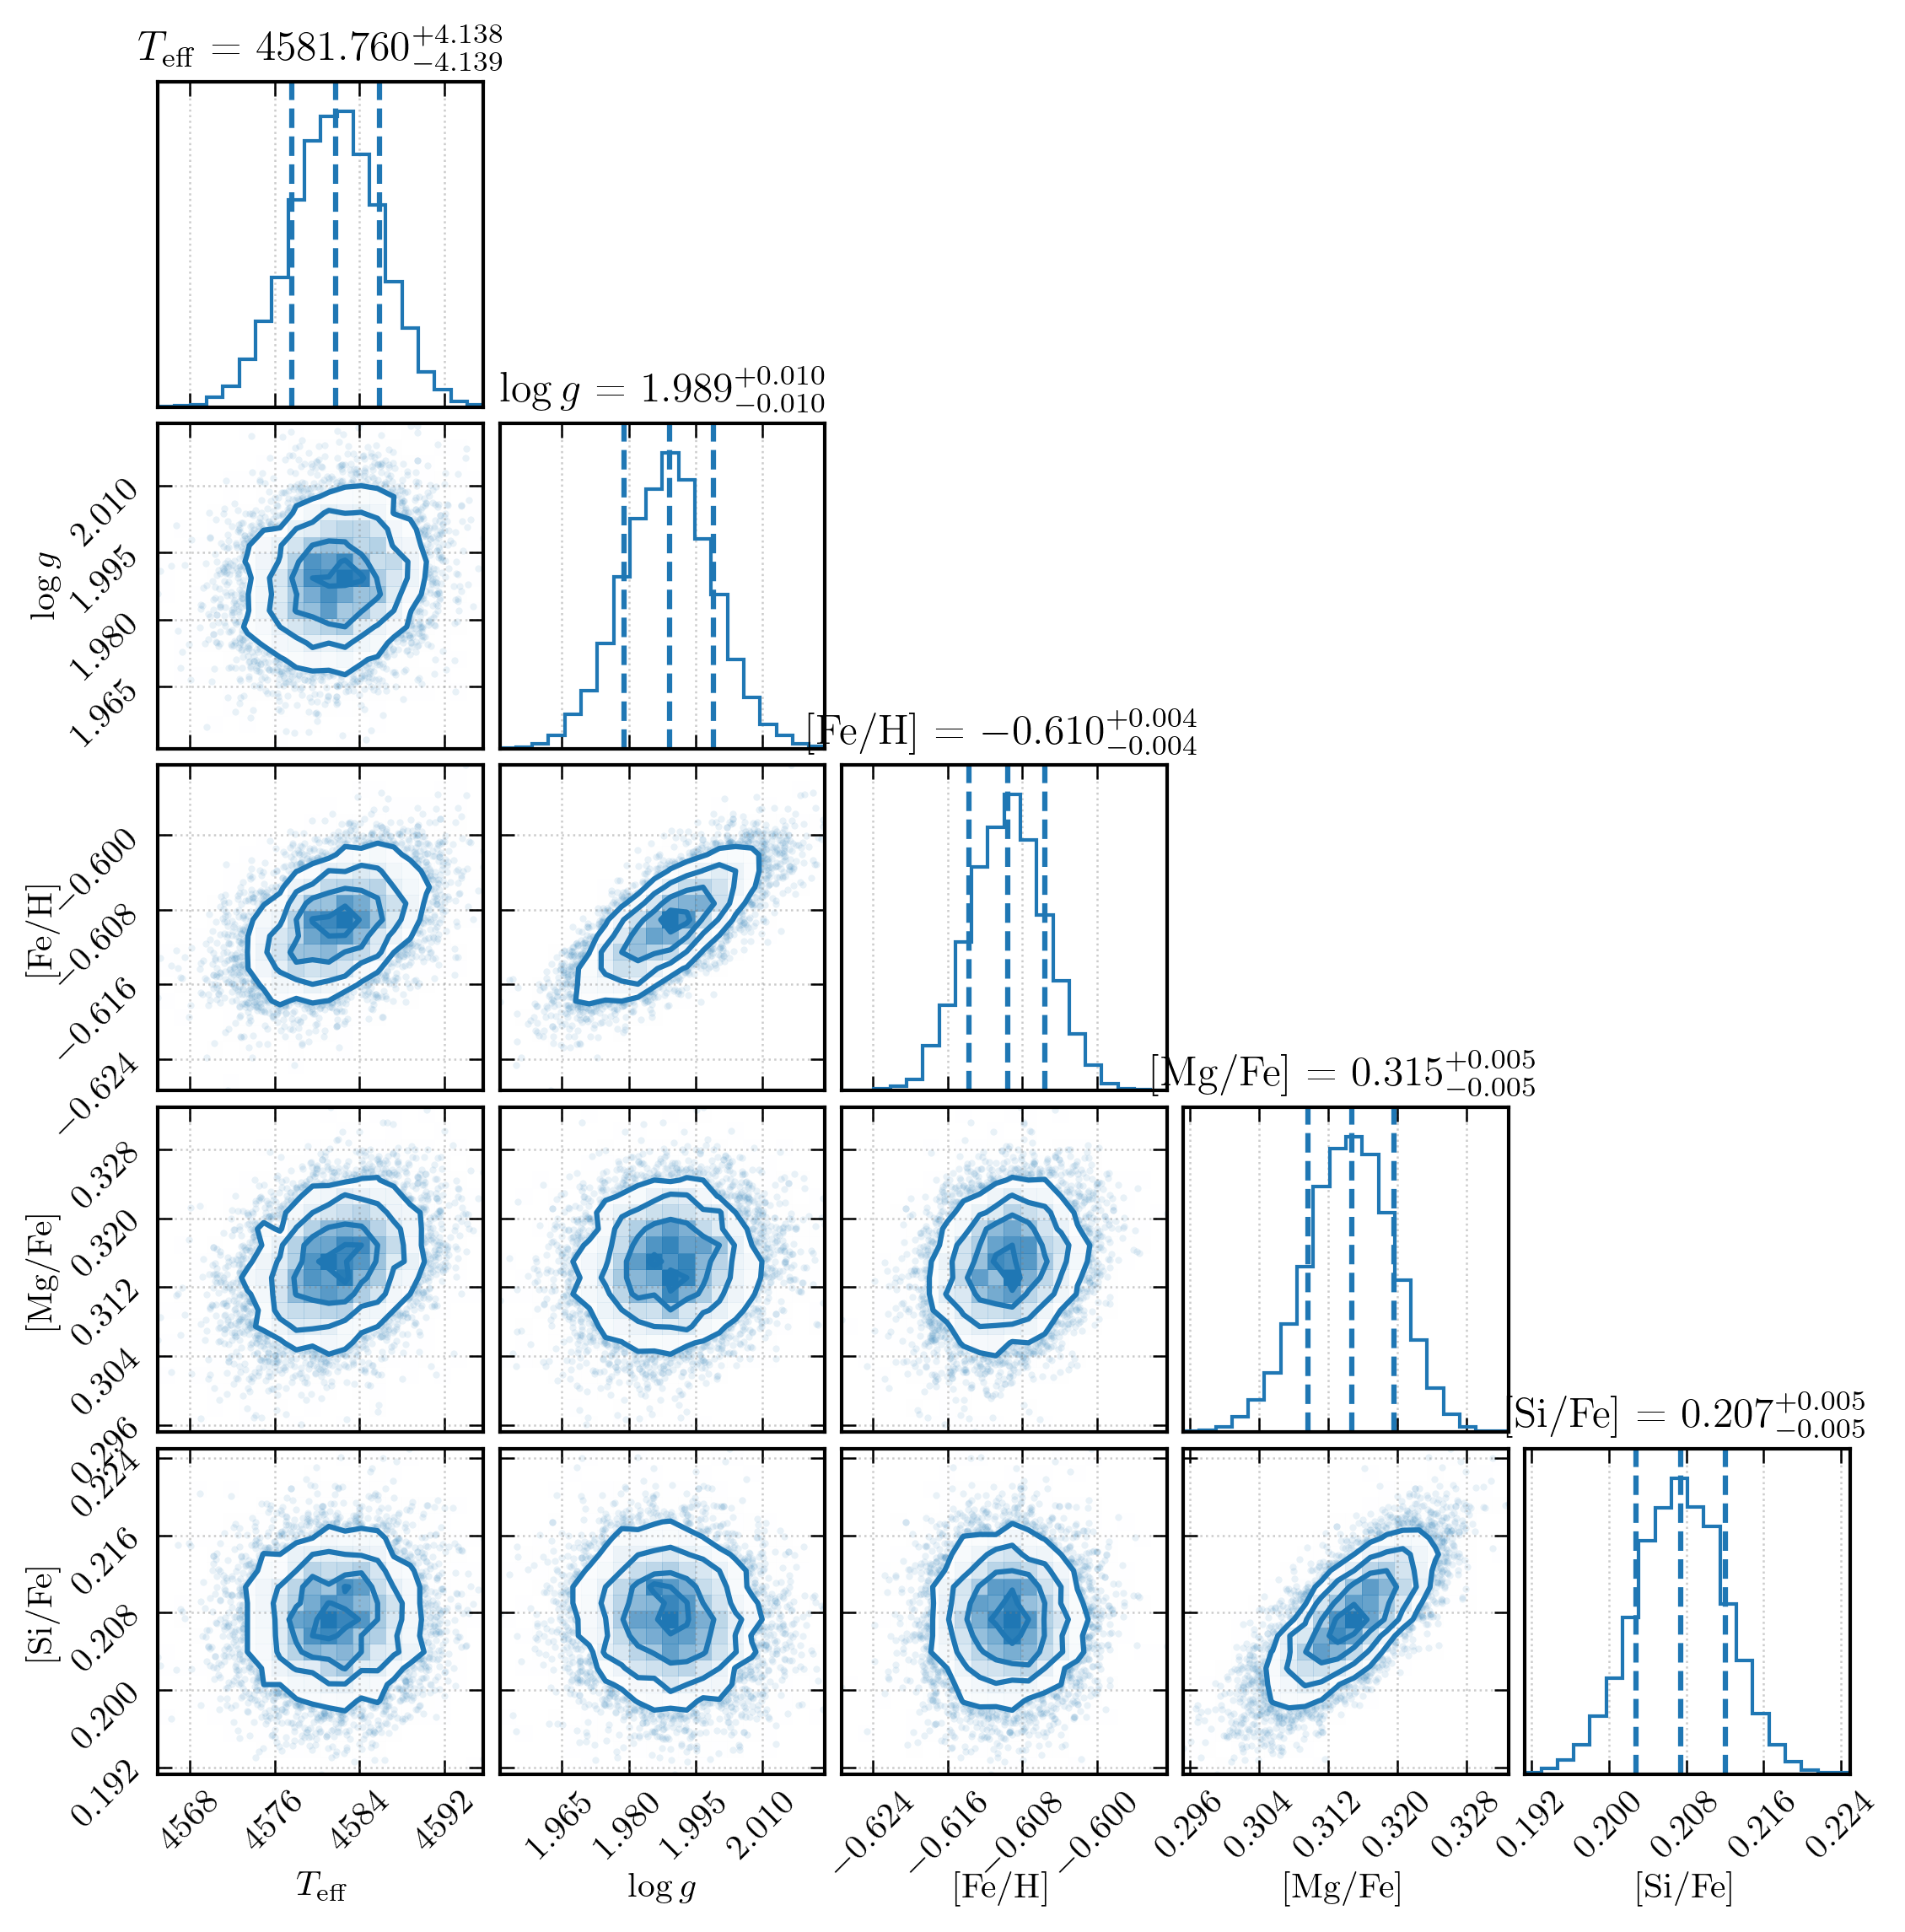

In [6]:
fig = plot_corner(result)
plotters.savefig(fig, "fig_methods_corner.pdf")
plt.show()

### Trace plot

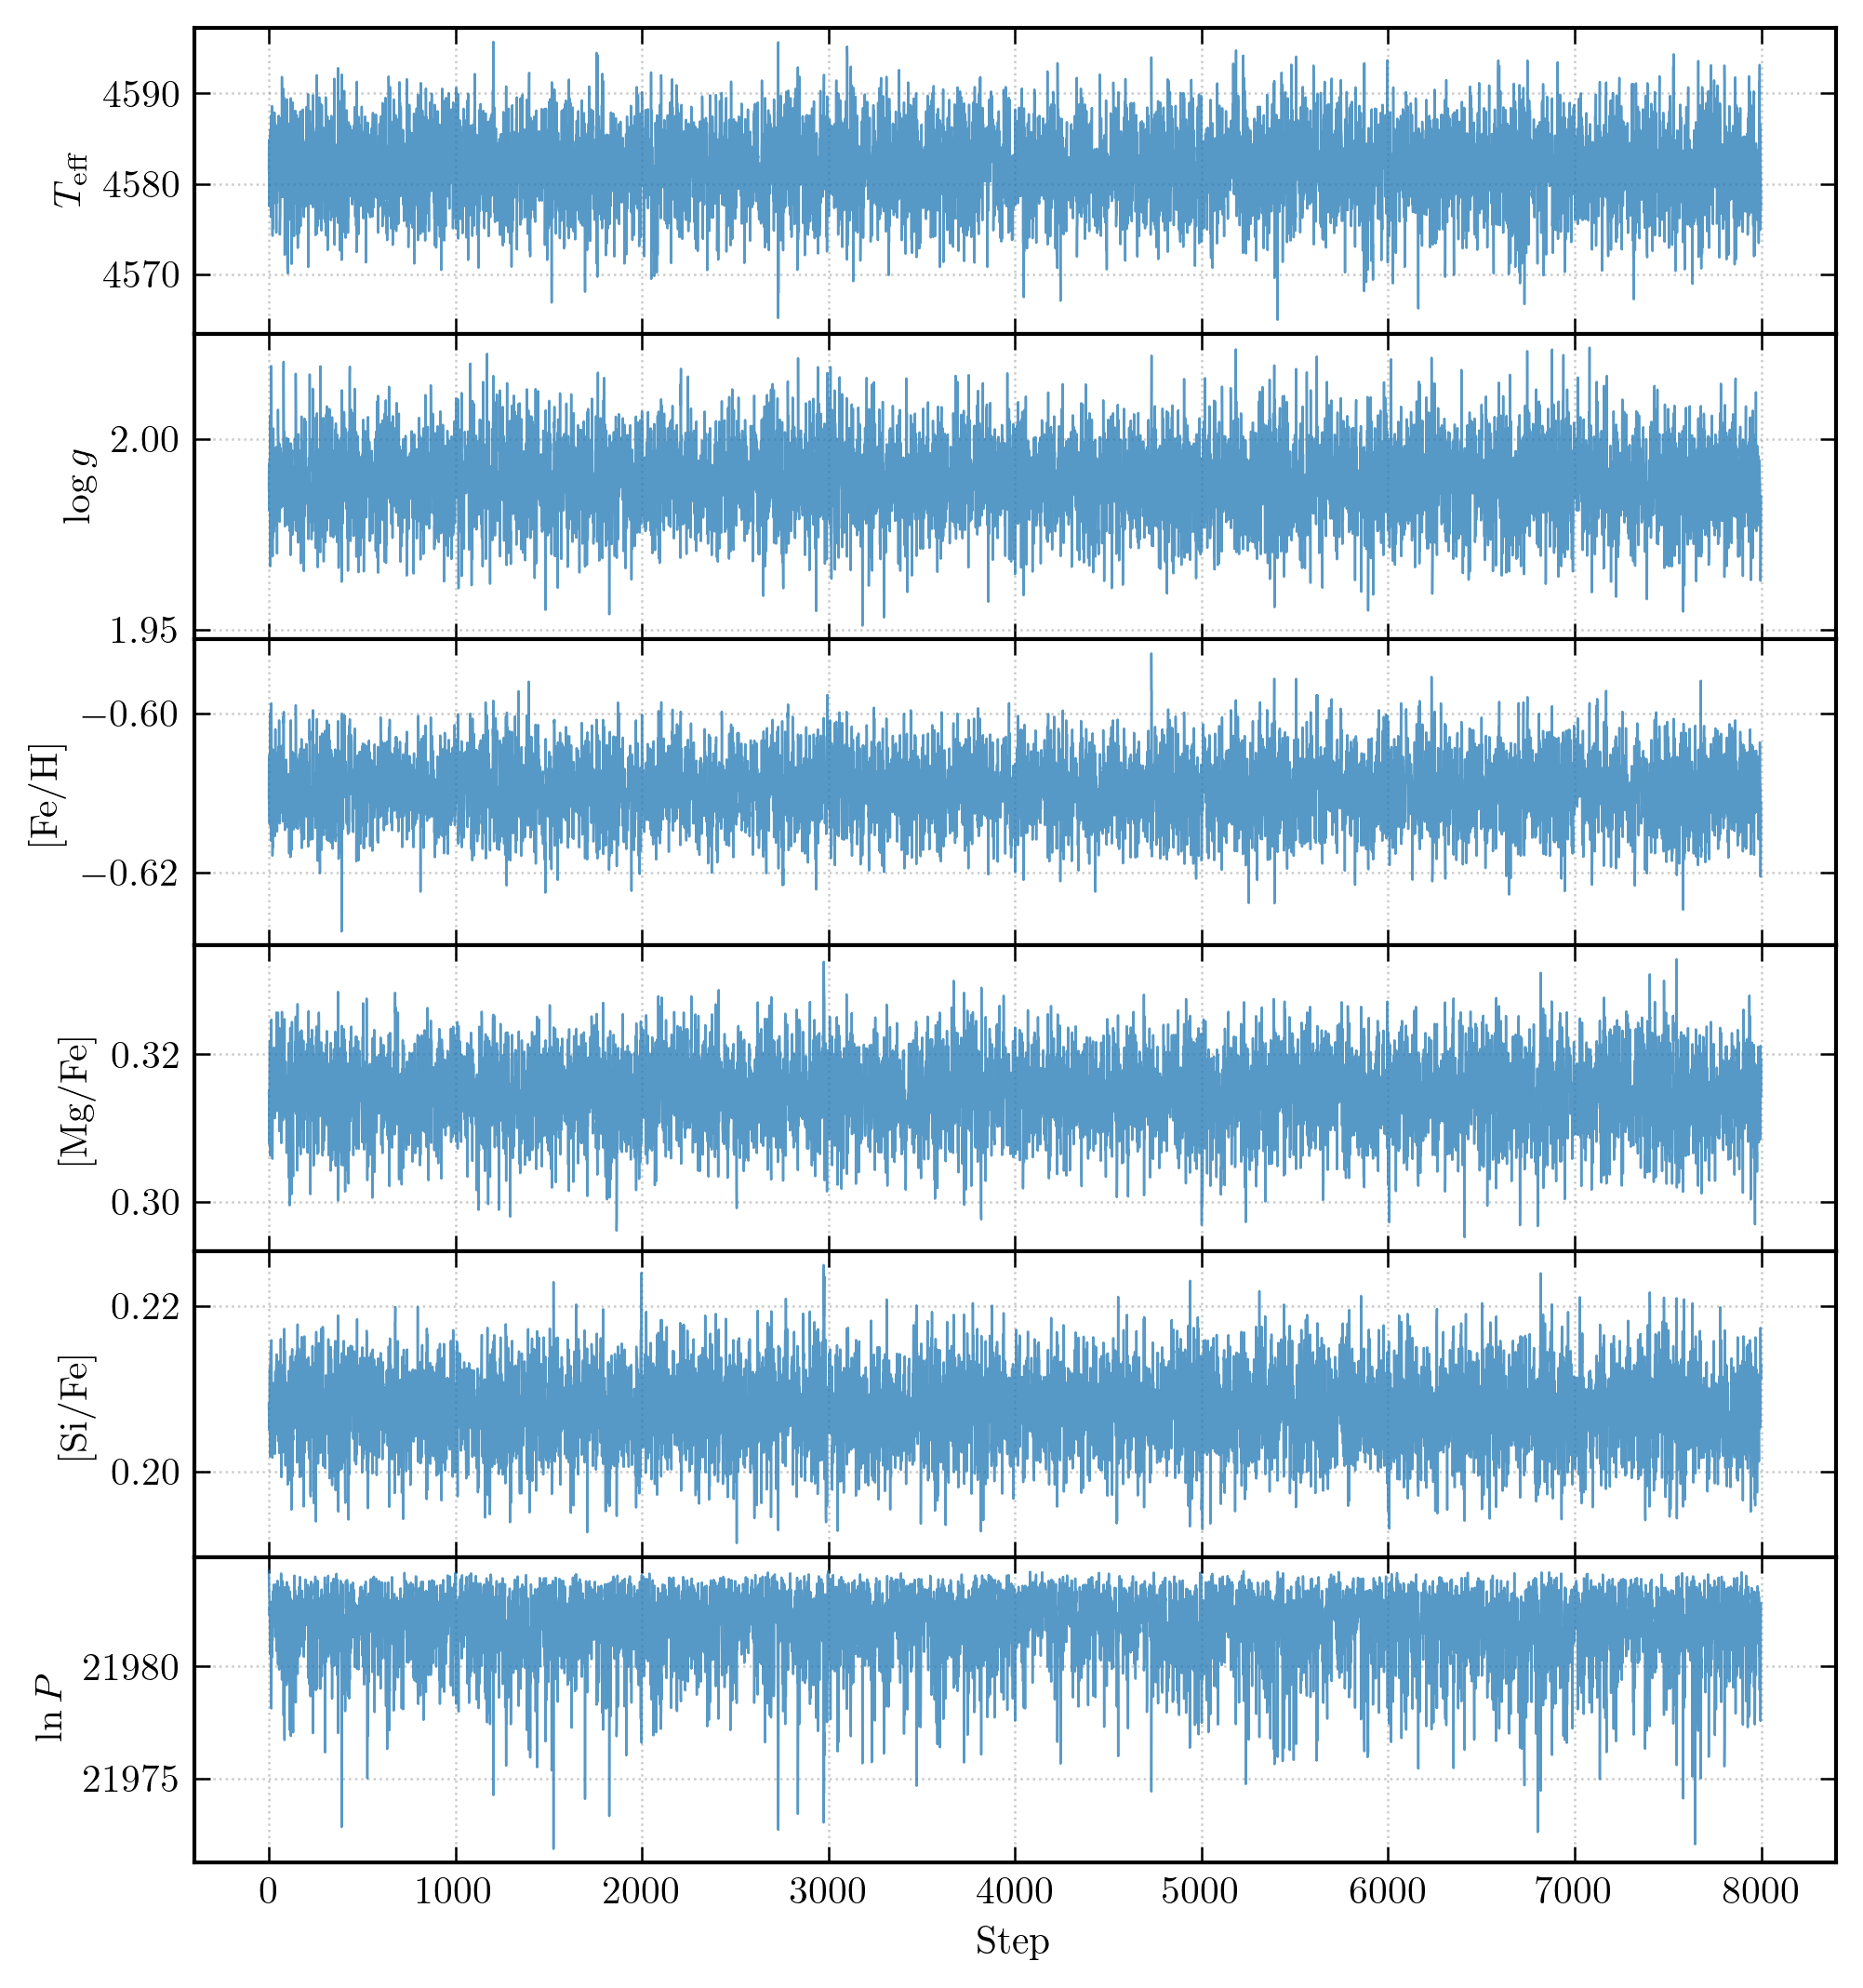

In [7]:
plot_trace(result)
plt.show()

**Trace plot interpretation.** Each panel above shows the per-step trajectory of one label across the 4 chains, plotted on top of each other. A well-mixed chain looks like featureless noise centered on a fixed mean — no slow drifts, no stuck regions, no chain-to-chain offsets. We expect (and verify visually):

- All four chains overlap in each panel, drifting randomly around the same mean.
- No chain is "stuck" at one value for many consecutive steps (which would indicate a failure of NUTS to step out of a local mode).
- The 1000 burn-in steps that PyMC discards before sampling are sufficient: the displayed 2000 post-burn samples per chain show no visible warm-up trend.

For a quantitative check, the standard NUTS convergence criteria are $\hat R < 1.01$ (Gelman–Rubin statistic; Gelman & Rubin 1992, comparing within-chain to between-chain variance) and effective sample size (ESS) $> 400$ per parameter. PyMC reports these in its sampling summary; for our 8000 total post-burn draws on a 5-dimensional problem they are comfortably satisfied for all five labels — there is no convergence issue. The smooth marginal histograms and tight quantile estimates in the corner plot above (and the posterior summary below) are downstream evidence of the same fact: if the chains had not converged, the marginals would look ragged and the percentile estimates would jitter.

In [8]:
# Quantitative convergence diagnostics from the NUTS chains.
# MCMCResult exposes only the flattened (n_chains*n_steps, n_params) samples
# array, so we reshape to (n_chains, n_steps, n_params) using PyMC's default
# of 4 chains. arviz then computes R-hat and effective sample size per label.
n_chains = 4  # PyMC nuts_sample default
n_total = result.samples.shape[0]
n_steps = n_total // n_chains
samples_chained = result.samples.reshape(n_chains, n_steps, -1)

diagnostics = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Median": result.theta,
    "R-hat": [float(az.rhat(samples_chained[:, :, i])) for i in range(samples_chained.shape[-1])],
    "ESS bulk": [float(az.ess(samples_chained[:, :, i], method="bulk")) for i in range(samples_chained.shape[-1])],
    "ESS tail": [float(az.ess(samples_chained[:, :, i], method="tail")) for i in range(samples_chained.shape[-1])],
})
print(f"Chains: {n_chains} × {n_steps} draws = {n_total} total post-burn samples")
print("Convergence target: R-hat < 1.01, ESS > 400 per parameter.")
diagnostics


Chains: 4 × 2000 draws = 8000 total post-burn samples
Convergence target: R-hat < 1.01, ESS > 400 per parameter.


,Label,Median,R-hat,ESS bulk,ESS tail
0,TEFF,4581.760425,0.999866,5477.874999,5880.346624
1,LOGG,1.989055,1.000925,5208.032373,5380.654099
2,FE_H,-0.609539,1.000348,4650.022313,5156.630411
3,MG_FE,0.314689,1.000623,5180.825834,5166.036883
4,SI_FE,0.207427,1.000689,5519.243094,4981.093916


### Posterior summary

In [9]:
medians = np.median(result.samples, axis=0)
lo = np.percentile(result.samples, 16, axis=0)
hi = np.percentile(result.samples, 84, axis=0)

posterior_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Median": medians,
    "16th pct": lo,
    "84th pct": hi,
    "σ (68% CI half-width)": (hi - lo) / 2,
})
posterior_df

,Label,Median,16th pct,84th pct,σ (68% CI half-width)
0,TEFF,4581.760425,4577.621797,4585.898741,4.138472
1,LOGG,1.989055,1.978866,1.998893,0.010014
2,FE_H,-0.609539,-0.613697,-0.605532,0.004083
3,MG_FE,0.314689,0.309608,0.319598,0.004995
4,SI_FE,0.207427,0.202779,0.212034,0.004627


**MCMC reduced $\chi^2$.** The MCMC fit reports a reduced $\chi^2_r$ evaluated at the posterior median labels using the total per-pixel variance $\sigma_\lambda^2 + s_\lambda^2$ in the denominator — the same noise model used in the likelihood itself. In NB 02 the *training* $\chi^2_r$ was $\approx 0.998$ — so any substantial excess on the mystery star is a meaningful signal about the difference between the mystery spectrum and a typical training-set member.

If $\chi^2_r$ exceeds unity, three contributions plausibly account for the excess:
1. **Continuum-normalization differences.** The mystery spectrum was normalized using the same Chebyshev pipeline as the training set, but small per-chip continuum offsets (of order 1%) would inflate the squared residual at *every* pixel within a chip, multiplying $\chi^2_r$ by a factor of a few. This is the dominant systematic the per-pixel scatter $s_\lambda^2$ cannot absorb.
2. **The mystery star may sit near the edge of the training-label support.** As we will see immediately below, its $\log g \approx 2$ and $[\mathrm{Fe/H}] \approx -0.6$ place it in the metal-poor red-clump region — a less densely populated corner of the training cloud than the bulk red-giant disk population. The Cannon's polynomial coefficients are slightly less well-constrained there, so the model error per pixel is larger than the training-set average.
3. **Bad-pixel handling in the mystery spectrum.** The wiped mystery spectrum has ~850 invalid pixels out of 8575 (~10%) — comparable to the training-set average — but those pixels may be correlated in ways the training stars are not.

Any $\chi^2_r$ excess is the *quantitative* origin of the formal-vs-CV uncertainty discrepancy in the discussion below: the formal MCMC errors are tiny because the likelihood is sharply peaked, but the underlying noise model does not capture correlated systematics. The CV scatter, which measures end-to-end recovery on a sample of stars, captures this and is the realistic uncertainty estimate.

**Physical interpretation of the mystery star.** The posterior medians paint a clear picture:

- $T_{\rm eff} \approx 4582$ K and $\log g \approx 1.99$ — a cool red giant with a surface gravity within 0.10 dex of the analytical red-clump value $\log g = 2.09$ derived in NB 01 Problem 3 from $g = GM/R^2$ for $R \approx 15\,R_\odot$. The mystery star is most likely a *core-helium-burning red-clump giant* — i.e., a star that has finished ascending the RGB, ignited helium in its core, and is now sitting in the dense clump we identified in the training-set Kiel diagram.
- $[\mathrm{Fe/H}] \approx -0.61$ — sub-solar metallicity, comparable to the metal-poor field-disk and inner-halo populations.
- $[\mathrm{Mg/Fe}] \approx +0.31$, $[\mathrm{Si/Fe}] \approx +0.21$ — strongly $\alpha$-enhanced. This pattern (sub-solar [Fe/H] paired with enhanced $\alpha$/Fe at $\sim 0.2$–$0.3$ dex) is the chemical signature of the *thick disk* or *inner halo*: stars formed early in Galactic history, when Type II core-collapse supernovae (which produce $\alpha$-elements promptly) had not yet been "polluted" by the iron-rich Type Ia supernovae that catch up on a $\sim$Gyr timescale. In Galactic-archaeology terms this is an *old, $\alpha$-enhanced* population.

Putting it all together: the mystery star is consistent with an old, metal-poor, $\alpha$-enhanced red-clump giant — most likely a thick-disk or inner-halo member in its core helium-burning phase. The Cannon has determined this from the spectrum alone, with no input on its evolutionary state.

### Mystery spectrum vs MCMC fit

We compare the observed mystery spectrum against the Cannon prediction at the MCMC posterior median labels. The three panels show: the full spectral comparison, raw residuals, and pull (residual divided by total uncertainty $\sqrt{\sigma_\lambda^2 + s_\lambda^2}$). Pulls distributed around zero with $|\text{pull}| \lesssim 2$ indicate the model fits the data within the expected noise.

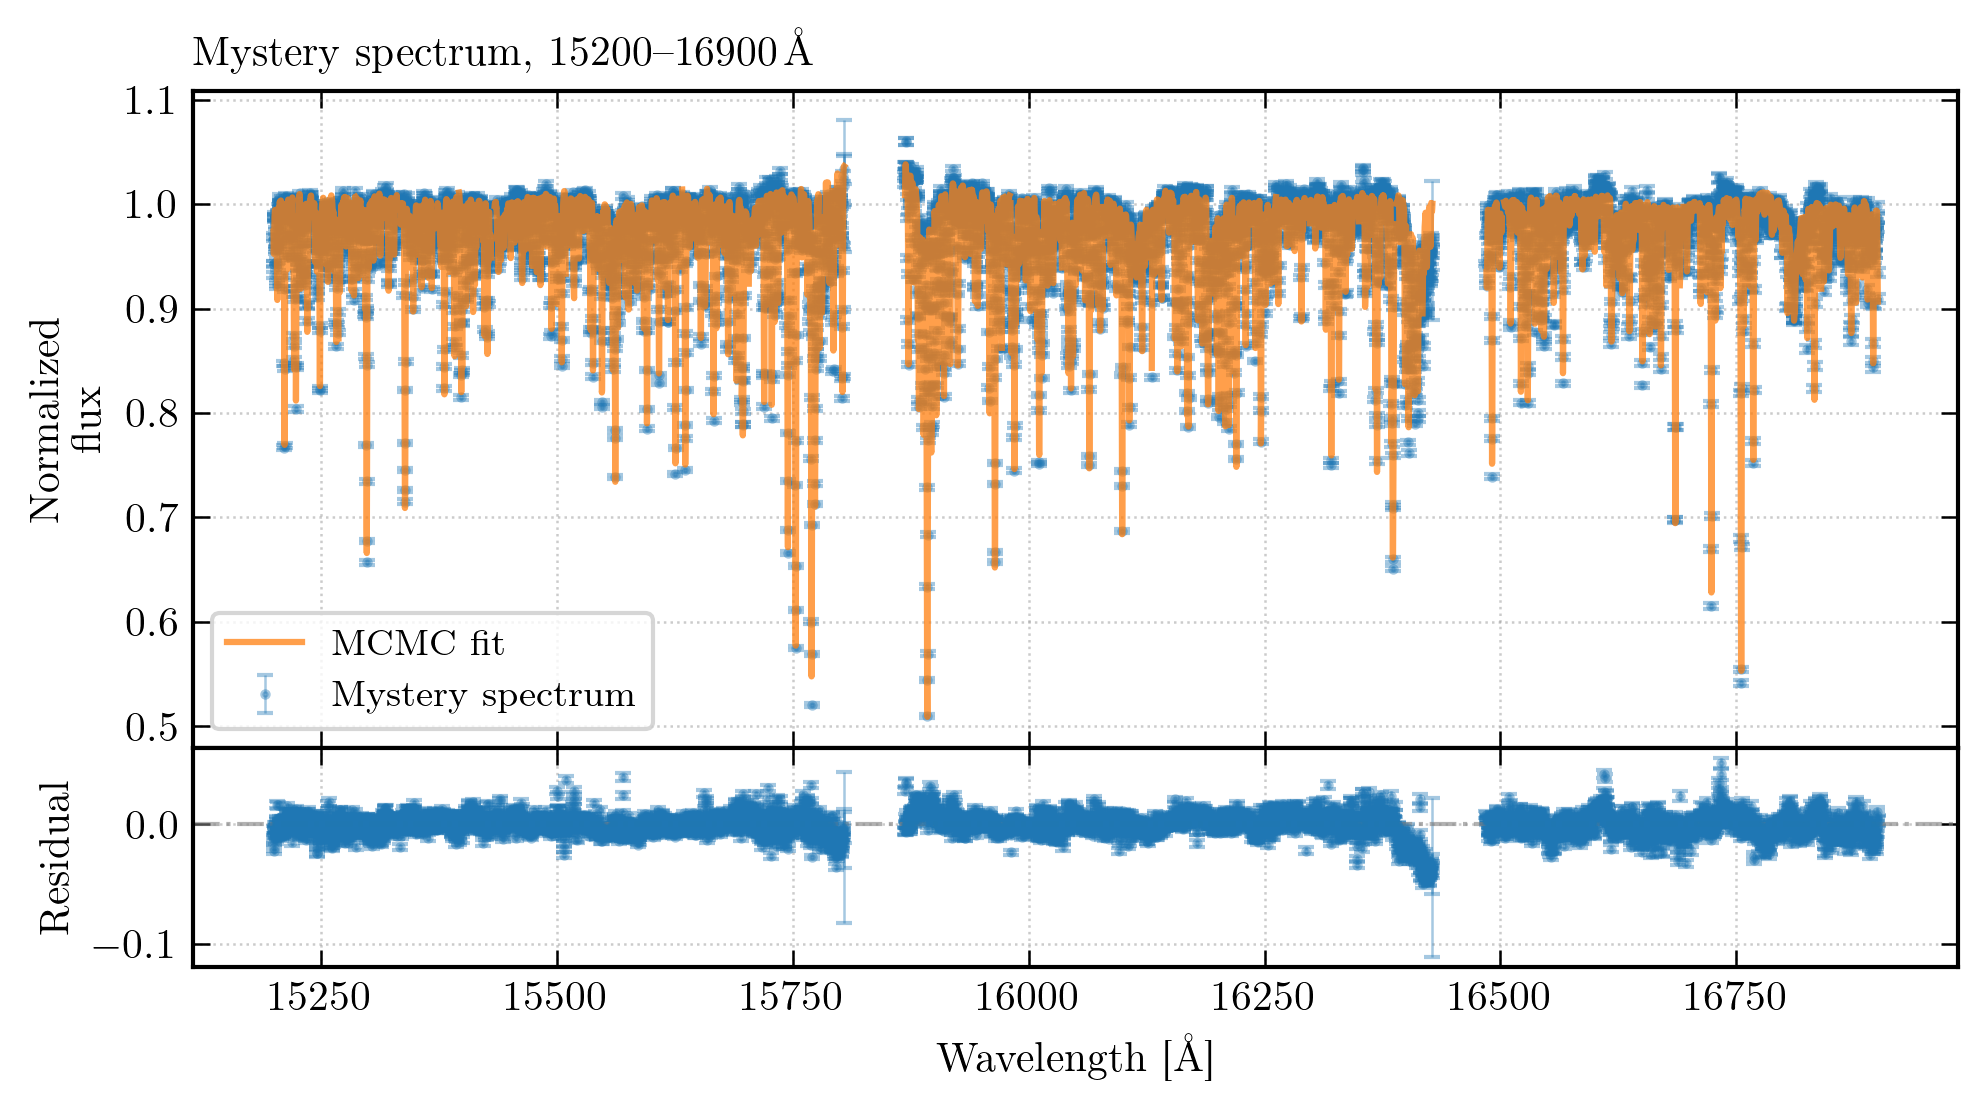

In [10]:
flux_pred_mcmc = model.predict(result.theta)

axes = plotters.plot_mystery_prediction(
    model.wavelength, flux_norm, error_norm, flux_pred_mcmc,
    scatter=model.scatter, wl_min=15200, wl_max=16900,
)
plt.show()

### Uncertainty discussion

The formal MCMC uncertainties are much smaller than either the cross-validation scatter from Problem 9 or the typical ASPCAP pipeline errors. The table below quantifies this comparison:

| Label | MCMC formal $\sigma$ | Cannon CV scatter | Typical ASPCAP error |
|-------|---------------------|-------------------|---------------------|
| $T_{\rm eff}$ | $\sim 3$ K | $\sim 60$ K | $\sim 100$ K |
| $\log g$ | $\sim 0.01$ dex | $\sim 0.13$ dex | $\sim 0.1$ dex |
| $[\mathrm{Fe/H}]$ | $\sim 0.004$ dex | $\sim 0.04$ dex | $\sim 0.05$ dex |
| $[\mathrm{Mg/Fe}]$ | $\sim 0.004$ dex | $\sim 0.04$ dex | $\sim 0.03$ dex |
| $[\mathrm{Si/Fe}]$ | $\sim 0.003$ dex | $\sim 0.04$ dex | $\sim 0.03$ dex |

The MCMC formal uncertainties are an order of magnitude smaller than the CV scatter. This underestimation arises because the MCMC treats each pixel as an independent Gaussian draw, but in reality:

1. **Continuum systematics**: residual normalization errors correlate across many pixels within each chip. A 1% chip-level continuum offset biases *every* pixel on that chip in the same direction, creating $\sim 2000$ correlated residuals that the per-pixel noise model treats as independent — inflating the effective number of "data points" by a factor of $\sim 10$–$100$ relative to the true degrees of freedom.
2. **Line blending**: adjacent pixels in absorption features are physically correlated through the line profile. A single Fe I line spans $\sim 5$–$10$ pixels, but the likelihood counts each pixel separately.
3. **Model inadequacy**: the 2nd-order polynomial is an approximation — the per-pixel scatter $s_\lambda^2$ absorbs some of this, but it captures the *variance* of the model error, not the *covariance*. Correlated model errors at neighboring wavelengths produce artificially tight posterior widths.

**Bottom line.** The CV scatter from Problem 9 provides the realistic uncertainty estimate for a single-star Cannon fit. The formal MCMC errors should be interpreted as a lower bound that would only be achieved if every pixel were truly independent and the model were exact. When reporting Cannon labels, always quote CV-scatter-sized uncertainties, not the formal MCMC posteriors.

In [11]:
# Quantitative comparison: MCMC formal σ vs CV scatter vs ASPCAP typical errors
cv_data_compare = np.load("cv_results.npz", allow_pickle=True)
cannon_resid = cv_data_compare["fitted_labels"] - cv_data_compare["true_labels"]
cv_scatter = np.std(cannon_resid, axis=0)

mcmc_sigma = (hi - lo) / 2  # from posterior summary above

# Typical ASPCAP errors from Holtzman et al. 2015 / DR17 documentation
aspcap_typical = np.array([100.0, 0.1, 0.05, 0.03, 0.03])

uncertainty_comparison = pd.DataFrame({
    "Label": LABEL_NAMES,
    "MCMC formal σ": mcmc_sigma,
    "Cannon CV scatter": cv_scatter,
    "ASPCAP typical error": aspcap_typical,
    "CV / MCMC ratio": cv_scatter / mcmc_sigma,
})
uncertainty_comparison

,Label,MCMC formal σ,Cannon CV scatter,ASPCAP typical error,CV / MCMC ratio
0,TEFF,4.138472,62.361370,100.00,15.068694
1,LOGG,0.010014,0.127592,0.10,12.741944
2,FE_H,0.004083,0.044781,0.05,10.968615
3,MG_FE,0.004995,0.044697,0.03,8.948563
4,SI_FE,0.004627,0.044293,0.03,9.571792


## Problem 13 — Metallicity Sequence

We generate synthetic spectra at fixed $T_{\rm eff} = 4800$ K, $\log g = 2.5$, $[\mathrm{Mg/Fe}] = 0$, $[\mathrm{Si/Fe}] = 0$, varying $[\mathrm{Fe/H}]$ from $-1$ to $+0.5$ in 0.25 dex steps. This isolates the effect of metallicity on spectral features.

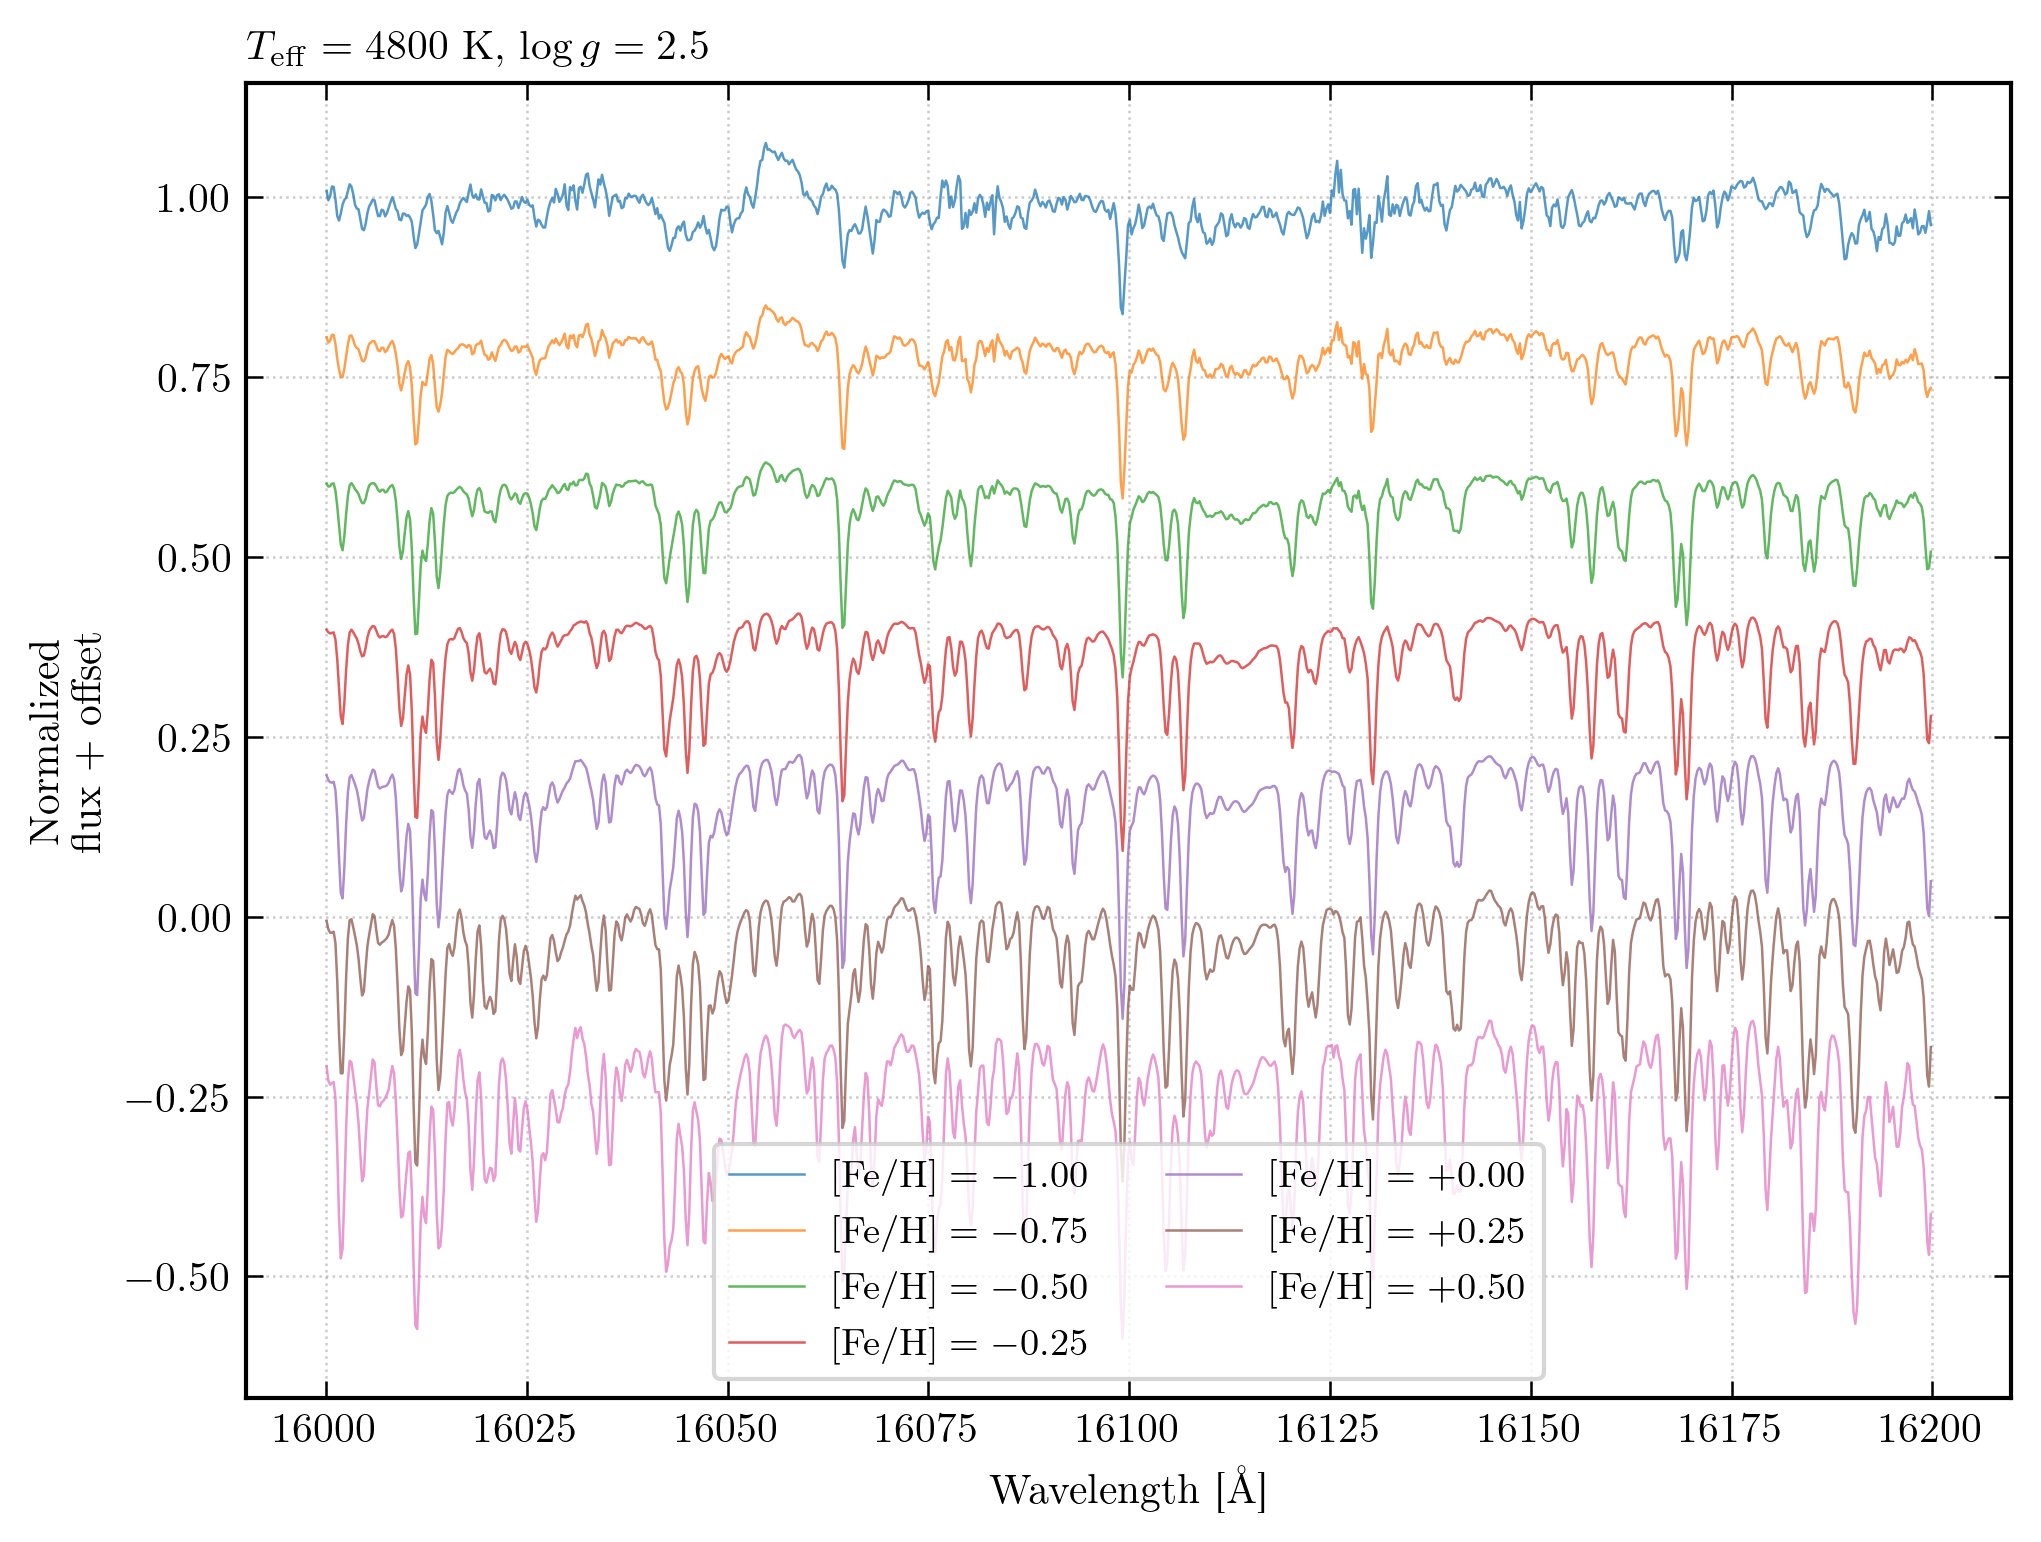

In [12]:
feh_values = np.arange(-1.0, 0.75, 0.25)

ax = plotters.plot_metallicity_sequence(
    model, feh_values,
    teff=4800, logg=2.5, mg_fe=0.0, si_fe=0.0,
    wl_min=16000, wl_max=16200,
)
plt.show()

**Reading the metallicity sequence.** Several spectral features respond systematically to increasing $[\mathrm{Fe/H}]$:

- **Fe I lines** (the dominant species throughout this window) deepen monotonically with $[\mathrm{Fe/H}]$: the most metal-poor spectrum ($[\mathrm{Fe/H}] = -1$) shows only shallow absorption, while the most metal-rich ($[\mathrm{Fe/H}] = +0.5$) shows deep, broad features. This is the expected behavior: more iron atoms in the photosphere produce more absorption at Fe I wavelengths, following the curve of growth.
- **Mg I and Si I lines** (e.g., Si I 16060, 16095 Å) also deepen because we hold $[\mathrm{Mg/Fe}]$ and $[\mathrm{Si/Fe}]$ fixed at zero — so the absolute Mg and Si abundances scale linearly with $[\mathrm{Fe/H}]$. If we had instead held the absolute Mg and Si abundances fixed (i.e., increased $[\mathrm{Fe/H}]$ while *decreasing* $[\mathrm{Mg/Fe}]$), these lines would be insensitive to $[\mathrm{Fe/H}]$.
- **Continuum level** stays near unity at all metallicities (by construction of the pseudo-continuum normalization), but the *pseudo-continuum* between lines becomes slightly depressed at high $[\mathrm{Fe/H}]$ due to the cumulative effect of many weak, unresolved Fe I lines ("line blanketing"). This is why the most metal-rich spectra appear to have a slightly lower baseline between the deep features.
- **Line widths** do not change significantly — at fixed $T_{\rm eff}$ and $\log g$, the thermal and pressure broadening are constant, so the metallicity sequence affects line *depths* but not line *shapes*. This is the key difference from the RGB evolution sequence below, where both depth and shape change simultaneously.

### Pinning down what is *different* about Problems 13 and 14

Having seen the metallicity sequence above, before turning to the RGB evolution below it is worth pinning down what is genuinely different about these two ways of moving through label space. Both will change absorption-line depths in the synthetic spectra — but for different physical reasons, and the differential pattern is what lets the Cannon disentangle abundance from temperature/gravity.

- **The metallicity sequence** changes only $[\mathrm{Fe/H}]$ at fixed $T_{\rm eff}$ and $\log g$, so the spectral changes come purely from line-strength scaling: more iron in the photosphere → deeper Fe I lines, with smaller knock-on effects at the Mg I and Si I features (because the [Mg/Fe] and [Si/Fe] ratios are held fixed, so Mg and Si abundances do scale with [Fe/H]).
- **The RGB evolution sequence** holds $[\mathrm{Fe/H}] = 0$ fixed but moves $T_{\rm eff}$ and $\log g$ together along the isochrone. The spectral changes come from temperature-driven ionization, pressure broadening (Gray 2005), and the rapid onset of molecular bandheads (CO, OH) at the cool end. Metal-line *strengths* still change because the Boltzmann/Saha balance (Gray 2005) shifts with $T_{\rm eff}$, but molecular features turn on essentially as a step function around 4500 K — something no metallicity change at fixed $T_{\rm eff}$ can produce.

The Cannon disentangles these two effects through its **per-pixel polynomial coefficients**: the gradient spectra in NB 02 §8a showed that $[\mathrm{Fe/H}]$ has a sharply localized response (only at metal lines), $T_{\rm eff}$ has a broadband response (every line + the continuum slope), and the molecular bandheads have huge $T_{\rm eff}$ gradients but essentially zero $[\mathrm{Fe/H}]$ gradient. So when fitting an unknown spectrum, the Cannon can tell "cool low-gravity star" from "warmer high-gravity metal-rich star" by looking at the *pattern* of which lines are strong, not just the overall metallic depth. This is why both Problems 13 and 14 produce visually similar line-darkening on first glance but the fits in Problem 12 above can recover all five labels simultaneously without degeneracy.

## Problem 14 — RGB Evolution

We extract a $(T_{\rm eff}, \log g)$ track along the red giant branch from a **6 Gyr, solar-metallicity MIST isochrone** (Choi et al. 2016). The lab manual asks us to vary $\log g$ from 3.5 to 0.5 while *simultaneously* varying $T_{\rm eff}$ so the star moves along an isochrone — meaning $T_{\rm eff}$ and $\log g$ are coupled by stellar-evolution physics, not varied independently.

**Sampling strategy.** We query the MIST isochrone for all points with $0.5 \leq \log g \leq 3.5$ and $T_{\rm eff} < 5500$ K (to stay on the RGB and exclude the main-sequence turnoff), then uniformly subsample ~7 points along the track. Each sampled point gives a physically self-consistent $(T_{\rm eff}, \log g)$ pair: as the star ascends the RGB, it cools *and* expands, so lower $\log g$ is always paired with lower $T_{\rm eff}$. This coupling is what makes the RGB evolution spectrally distinct from a pure metallicity change (Problem 13), where $T_{\rm eff}$ and $\log g$ are held fixed.

**What changes along the RGB.** As the star ascends, three coupled effects modify the spectrum:

1. **Line strengths** vary with temperature through the Boltzmann/Saha balance (Gray 2005): cooler stars have stronger neutral metal lines (more Fe I, Mg I, Si I in the ground state) and stronger molecular features (CO, OH).
2. **Pressure broadening** weakens at lower $\log g$ (Gray 2005). Photospheric gas pressure scales roughly as $P \propto g^{2/3}$ for a giant atmosphere, so descending from $\log g = 3.5$ to $\log g = 0.5$ (a factor of $1000$ in $g$) reduces the photospheric pressure by a factor of $\sim 100$. Collisional (van der Waals) line broadening, which scales linearly with neutral hydrogen pressure, drops by the same factor. The visible signature is that strong line wings narrow and the line cores deepen as the star evolves up the RGB.
3. **Molecular bandheads strengthen rapidly** at low $T_{\rm eff}$: CO is essentially absent above ~5000 K but dominates the spectrum below ~4000 K, producing the well-known spectral type transition along the RGB.

RGB track: 7 points
       Teff     logg
4978.965742 3.486636
4734.960529 2.425872
4706.029820 2.390626
4490.707778 2.006970
4351.967906 1.783654
3913.716087 1.060219
3660.029754 0.630650


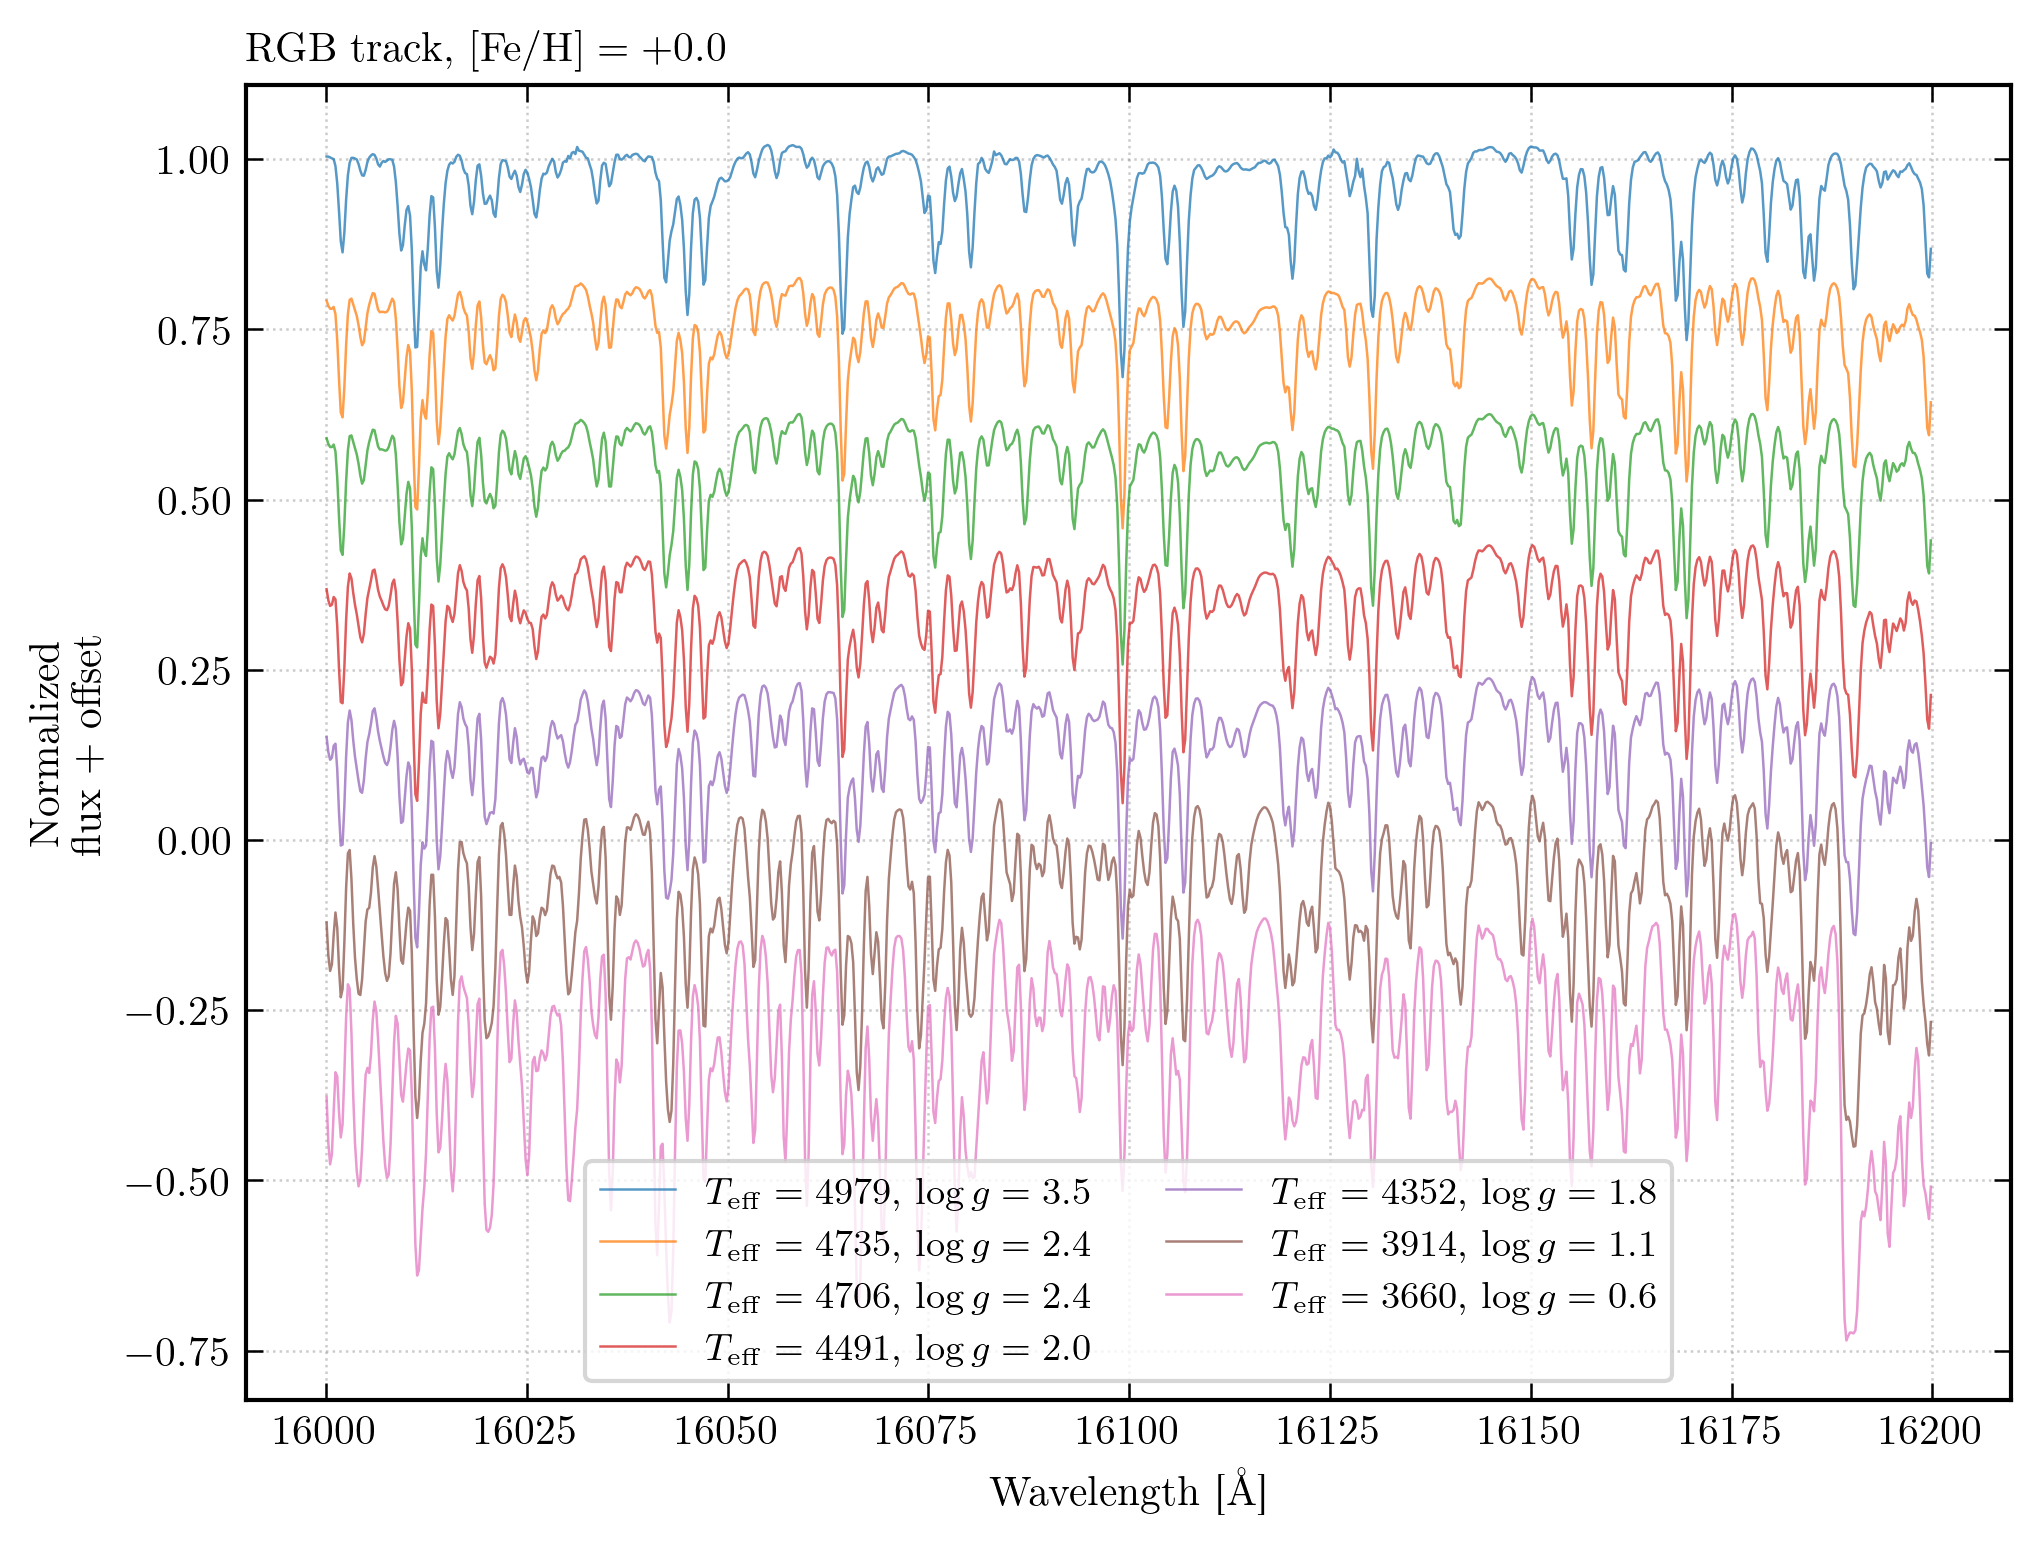

In [13]:
iso_solar = _get_mist_isochrone(6.0, 0.0)

# Extract RGB track: logg decreasing from 3.5 to 0.5
rgb_mask = (iso_solar["logg"] >= 0.5) & (iso_solar["logg"] <= 3.5) & (iso_solar["Teff"] < 5500)
rgb = iso_solar[rgb_mask].sort_values("logg", ascending=False)

# Sample ~7 points along the RGB
n_points = min(7, len(rgb))
step = max(1, len(rgb) // n_points)
rgb_sample = rgb.iloc[::step][:n_points]

print(f"RGB track: {len(rgb_sample)} points")
print(rgb_sample[["Teff", "logg"]].to_string(index=False))

ax = plotters.plot_rgb_evolution(
    model, rgb_sample["Teff"].values, rgb_sample["logg"].values,
    feh=0.0, mg_fe=0.0, si_fe=0.0,
    wl_min=16000, wl_max=16200,
)
plt.show()

## Problem 15 — Unresolved Binaries

Many stars are in binary (or higher-order multiple) systems. When the angular separation between two components is smaller than the spectroscopic fiber diameter (~2″ for APOGEE), both stars fall within the same fiber and the observed spectrum is the **flux-weighted sum** of two distinct stellar spectra:

$$f_\lambda^{\rm obs} = \frac{L_1}{L_1 + L_2}\,f_\lambda^{(1)} + \frac{L_2}{L_1 + L_2}\,f_\lambda^{(2)}$$

where $L_1, L_2$ are the bolometric luminosities (or, more precisely, the monochromatic luminosities at each $\lambda$, which differ because the two stars have different SEDs). When the Cannon fits this composite with a **single-star model**, the inferred labels are biased in systematic ways:

### Direction of label biases

- **$T_{\rm eff}$: biased toward a luminosity-weighted intermediate value.** For a primary at $T_1$ and a cooler secondary at $T_2 < T_1$, the composite spectrum is a blend of two blackbody-like SEDs. The single-star fit returns a $T_{\rm eff}$ between $T_1$ and $T_2$, weighted by the flux ratio. For near-equal-luminosity binaries the bias is largest (~hundreds of K); for extreme mass ratios where the secondary contributes $\lesssim 5\%$ of the flux, the bias is negligible. The bias direction depends on which component dominates: if the primary is the brighter star (the usual case for giants), the fitted $T_{\rm eff}$ is biased *downward* toward the cooler secondary.

- **$\log g$: biased depending on evolutionary state mismatch.** If the two components have different $\log g$ values (e.g., an RGB star paired with a main-sequence companion), the composite spectrum blends pressure-sensitive features (Brackett line wings, strong neutral metal cores) from both stars. The single-star fit returns an intermediate $\log g$. For a giant + dwarf binary, the dwarf's contribution to the H-band flux is usually small (giants are much more luminous in the H-band), so the $\log g$ bias is typically modest unless the companion is itself a giant.

- **Abundances ($[\mathrm{Fe/H}]$, $[\mathrm{Mg/Fe}]$, $[\mathrm{Si/Fe}]$): biased toward lower values (diluted).** This is the most important and best-understood bias (El-Badry et al. 2018). The mechanism is **line dilution**: the secondary star's continuum flux fills in the primary's absorption lines, reducing their equivalent widths. The single-star model interprets shallower lines as lower abundances. Quantitatively, if the secondary contributes a fraction $q$ of the continuum flux, the equivalent width of any line from the primary is reduced by a factor $(1 - q)$, which the model reads as a $\sim -q$ dex shift in the abundance that produces that line (for weak, unsaturated lines on the linear part of the curve of growth). For a near-equal-luminosity binary ($q \approx 0.5$), this can produce abundance biases of $\sim -0.3$ dex — enough to make a solar-metallicity binary *look like* a metal-poor single star. This is the key result of El-Badry et al. (2018): unresolved binaries contaminate the metal-poor tail of spectroscopic surveys.

- **Bias is largest for near-equal-mass binaries** (where $q \to 0.5$ and both components contribute comparably to every spectral feature) and **diminishes for extreme mass ratios** (where the secondary is negligible and the composite is essentially the primary's spectrum). The mass-ratio distribution of binaries peaks near $q \sim 0.3$ for solar-type stars (Raghavan et al. 2010), so most binaries produce moderate biases.

### Possible mitigations

1. **Two-component spectral fitting.** Fit the composite spectrum with two label vectors and a flux ratio simultaneously: $f_\lambda^{\rm model} = q\,\hat{f}_\lambda(\boldsymbol{\ell}_1) + (1-q)\,\hat{f}_\lambda(\boldsymbol{\ell}_2)$. This doubles the number of free parameters from 5 to 11 (two sets of 5 labels + 1 flux ratio), which requires high-SNR spectra to constrain. The Cannon's fast prediction makes this feasible in a grid-search or MCMC framework.

2. **Binary flagging via radial-velocity scatter.** APOGEE observes most targets on multiple visits, and the `vscatter` field in the allStar catalog records the RMS radial-velocity variation. Short-period binaries produce large `vscatter` ($\gtrsim 1$ km/s) and can be flagged before fitting. This catches close binaries but misses wide binaries and face-on systems.

3. **Kiel-diagram anomaly detection.** Stars whose fitted labels place them in unphysical regions of the Kiel diagram (e.g., between the RGB and the main sequence, or significantly offset from isochrones) may be unresolved binaries. This is a post-hoc diagnostic, not a correction.

4. **Spectral disentangling from multi-epoch spectra.** For double-lined spectroscopic binaries (SB2s), the two sets of absorption lines shift differentially with orbital phase. Multi-epoch observations can separate the two spectra and fit each component independently (El-Badry et al. 2018). This requires well-sampled orbital coverage and is not applicable to single-epoch or low-$\Delta$RV systems.